# <center> Decision Tree & Stacking Method</center>

In [1]:
import pandas as pd
import numpy as np
import math
import  matplotlib.pyplot as plt
from sklearn import tree
from sklearn.tree import plot_tree

# DT Classification

In [2]:
x1 = [1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0]
x2 = [0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0]
y = [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0] 
df = pd.DataFrame({'X1':x1,'X2':x2, 'Y':y})

In [3]:
from sklearn.tree import DecisionTreeClassifier

In [4]:
DT = DecisionTreeClassifier(criterion='entropy',max_depth=10)
X = df[['X1','X2']]
model = DT.fit(X,df.Y)

In [5]:
X_names = df.iloc[:,0:2].columns
X_names = list(X_names)
Y_name = ['Y']

In [6]:
text_representation = tree.export_text(DT)
print(text_representation)

|--- feature_1 <= 0.50
|   |--- feature_0 <= 0.50
|   |   |--- class: 0
|   |--- feature_0 >  0.50
|   |   |--- class: 1
|--- feature_1 >  0.50
|   |--- feature_0 <= 0.50
|   |   |--- class: 1
|   |--- feature_0 >  0.50
|   |   |--- class: 0



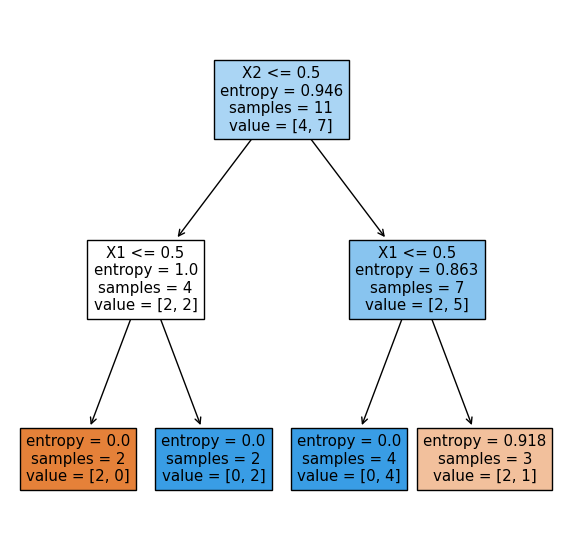

In [7]:
fig = plt.figure(figsize=(7,7))
_ = tree.plot_tree(DT, feature_names=X_names, filled=True)

In [8]:
from sklearn.metrics import accuracy_score
y_pred_d1 = DT.predict(X)

In [9]:
accuracy_score(df.Y, y_pred_d1)

0.9090909090909091

# DT Regression

In [10]:
from sklearn.tree import DecisionTreeRegressor

In [11]:
x = np.array([1,2,3,4,5,6,7,8,9,10,11,12,13,14]).reshape(-1,1)
y = np.array([1,1.2,1.4,1.1,1,5.5,6.1,6.7,6.4,6,6,3,3.2,3.1])
dt = DecisionTreeRegressor(max_depth=1)
dt.fit(x,y)
text_representation = tree.export_text(dt)
print(text_representation)

|--- feature_0 <= 5.50
|   |--- value: [1.14]
|--- feature_0 >  5.50
|   |--- value: [5.11]



In [12]:
from sklearn.metrics import mean_squared_error

In [13]:
dt = DecisionTreeRegressor(max_depth=100)
dt.fit(x,y)
pred = dt.predict(x)

In [14]:
mean_squared_error(y,pred)

0.0

# Stacking Method

In [2]:
from sklearn.datasets import load_iris
from sklearn.ensemble import StackingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

X, y = load_iris(return_X_y=True)

base_learners = [
                ('bl1', SVC(kernel='linear', C = 20)), ('bl2',KNeighborsClassifier(n_neighbors=100)),
                ('bl3', DecisionTreeClassifier(max_depth=10))
                ]
                
for name, model in base_learners:
    model.fit(X, y)
    score = model.score(X, y)
    print(f'{name} accuracy: {round(score, 3)}')

clf = StackingClassifier(estimators=base_learners, final_estimator=LogisticRegression())
result = clf.fit(X,y).score(X,y)
print(f'naive: {round(result,3)}')

clf = StackingClassifier(estimators=base_learners, final_estimator=LogisticRegression(), cv=10)
result = clf.fit(X,y).score(X,y)
print(f'cv: {round(result,3)}') 

bl1 accuracy: 0.98
bl2 accuracy: 0.66
bl3 accuracy: 1.0
naive: 0.98
cv: 0.98


In [3]:
base_learners_1 = [
                ('bl1', SVC(kernel='linear', C = 20)), ('bl2',KNeighborsClassifier(n_neighbors=100)),
                ('bl3', DecisionTreeClassifier(max_depth=10))
                ]
base_learners_2 = [
                ('bl1', SVC(kernel='rbf')), ('bl2',KNeighborsClassifier(n_neighbors=50)),
                ('bl3', DecisionTreeClassifier(max_depth=50))
                ]
layer_two = StackingClassifier(estimators=base_learners_2, final_estimator=LogisticRegression())

# Create Final model by 
clf = StackingClassifier(estimators=base_learners_1, final_estimator=layer_two)
result = clf.fit(X, y).score(X, y)
print(f'multi-layer:{round(result,3)}')

multi-layer:0.987
